# Introduction
This notebook provides a full training of a CNN, implemented with a popular architecture VGG16, 
commonly used in classification and detection in scope of machile learning. The dataset used for 
training is [CatBreedsRefined-7k](https://www.kaggle.com/datasets/doctrinek/catbreedsrefined-7k/code), 
taken from Kaggle. It consists of 7000 pictures of 20 different breeds of cats. The aim of the project 
is to design and train a model for recognising a cat's breed with only its picture provided. After
training the best model will be evaluated using a few different metrics.

**Author:** Marianna Palka

### Packages

In [11]:
import torch
from sklearn.preprocessing import LabelEncoder
import os
import torch.nn.init as init
import numpy as np
import cv2
import pandas as pd
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torchvision
import matplotlib.pyplot as plt
from PIL import Image
import time
from torch.optim.lr_scheduler import StepLR

In [12]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Dataset split

In [13]:
def make_dataframes(train_dir, test_dir = None , val_dir = None, min_images = None):
    bad_images=[]
    skip_classes=[]

    # Checking the existance of train, test and validation directories
    if test_dir == None and val_dir==None:
        dirlist = [train_dir]
        names = ['train']
    elif test_dir == None:
        dirlist = [train_dir, val_dir]
        names = ['train', 'valid']
    elif val_dir == None:
        dirlist = [train_dir, test_dir]
        names = ['train', 'test']
    else:
        dirlist = [train_dir, test_dir, val_dir]
        names = ['train','test','valid']

    ht = 0 # Height total
    wt = 0 # Weight total
    total_good_files = 0

    for name, dir in zip(names, dirlist):
        filepaths = [] # File paths for the pictures of cats
        labels = [] # True labels for the pictures
        classlist = sorted(os.listdir(dir)) # Names of all classes (breeds) in alphabetical order

        for cl in classlist:
            msg = f'Processing images in {name} directory for class {cl}'
            print(msg, '\r', end='')
            good_file_count = 0
            classpath = os.path.join(dir, cl) # Full path to the files of the class

            if os.path.isdir(classpath):
                flist = sorted(os.listdir(classpath)) # Full list of files prepared for the class+

                if name == 'train' and len(flist) < min_images:
                    skip_classes.append(cl)
                else:
                    if cl not in skip_classes:
                        for f in flist:
                            fpath = os.path.join(classpath, f) # Full path of the image
                            index = f.rfind('.')
                            ext = f[index+1:].lower() # Extract file extension
                            if ext not in ['jpg', 'jpeg', 'tiff', 'png', 'bmp'] :   # If extenstion is invalid
                                bad_images.append(fpath)
                            else:
                                try:
                                    img = cv2.imread(fpath)
                                    
                                    h = img.shape[0]
                                    w = img.shape[1]
                                    ht += h
                                    wt += w
                                    
                                    good_file_count += 1
                                    total_good_files += 1
                                    
                                    filepaths.append(fpath) # Add to valid pictures
                                    labels.append(cl)
                                except:
                                    bad_images.append(fpath) # Add to invalid pictures
        
        # Dataframe with filepaths and correct labels
        Fseries = pd.Series(filepaths, name='filepaths')
        Lseries = pd.Series(labels, name='labels')
        df = pd.concat([Fseries, Lseries], axis=1)
        
        # Creating dataframes for train, test and validation data (if they exist)
        if name =='valid':
            valid_df = df
        elif name == 'test':
            test_df = df
        else:
            if test_dir == None and val_dir == None:
                train_df, dummy_df = train_test_split(df, train_size=.8, shuffle=True, random_state=123, stratify=df['labels'])
                valid_df, test_df = train_test_split(dummy_df, train_size=.5, shuffle=True, random_state=123, stratify=dummy_df['labels'])
            elif test_dir == None:
                train_df, test_df=train_test_split(df, train_size=.8, shuffle=True, random_state=123, stratify=df['labels'])
            elif val_dir == None:
                train_df, valid_df=train_test_split(df, train_size=.8, shuffle=True, random_state=123, stratify=df['labels'])
            else:
                train_df = df

    classes = sorted(train_df['labels'].unique())
    class_count = len(classes)

    # Average height and width of an image
    h_ave = int(ht/total_good_files)
    w_ave = int(wt/total_good_files)


    print('Avarage size of the photo is: ', h_ave, ' x ', w_ave, '.')
    print('Number of classes in processed dataset = ', class_count)

    if len(skip_classes)>0:
        msg = f'Listed below are classes not included in the dataset because it had less than {min_images} training image files'
        for cl in skip_classes:
            print(cl)

    counts = list(train_df['labels'].value_counts())
    print('The maximum files in any class in train_df is ', max(counts), '. The minimum files in any class in train_df is ', min(counts))
    print('train_df length: ', len(train_df), '  test_df length: ', len(test_df), '  valid_df length: ', len(valid_df))

    if len(bad_images) == 0:
        print('All image files were properly processed and used in the dataframes')
    else:
        print(f'There are {len(bad_images)} bad image files and {total_good_files} proper image files in the dataset')
        for f in bad_images:
            print (f)

    return train_df, test_df, valid_df, classes, class_count

In [14]:
train_df, test_df, valid_df, classes, class_count = make_dataframes(train_dir = 'CatBreedsRefined-v2/', min_images = 100)

Avarage size of the photo is:  469  x  471 .ss Turkish Angora t   
Number of classes in processed dataset =  20
The maximum files in any class in train_df is  280 . The minimum files in any class in train_df is  280
train_df length:  5600   test_df length:  700   valid_df length:  700
All image files were properly processed and used in the dataframes


In [15]:
train_df.head()

,filepaths,labels
5386,CatBreedsRefined-v2/Russian Blue\Russian Blue_...,Russian Blue
1007,CatBreedsRefined-v2/American Curl\American Cur...,American Curl
4341,CatBreedsRefined-v2/Norwegian Forest\Norwegian...,Norwegian Forest
1992,CatBreedsRefined-v2/Birman\Birman_317.jpg,Birman
4286,CatBreedsRefined-v2/Norwegian Forest\Norwegian...,Norwegian Forest


In [16]:
label_encoder = LabelEncoder()
label_encoder.fit(classes)

LabelEncoder()

In [17]:
# Preparing dataset for a data loader
class CatBreedDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.cat_frame = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.cat_frame)

    def __getitem__(self, idx):
        img_name = self.cat_frame.iloc[idx, 0]
        image = Image.open(img_name)
        breed_name = self.cat_frame.iloc[idx, 1]
        label = label_encoder.transform([breed_name])[0]
        
        if self.transform:
            image = self.transform(image)

        return image, label

In [18]:
batch_size = 64

transform_train = torchvision.transforms.Compose([
    torchvision.transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=10), # Zastosowanie augumentacji danych
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # Parametry zaczerpnięte z papieru naukowego dot. architektury
])

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

cat_dataset_train = CatBreedDataset(dataframe=train_df, root_dir='CatBreedsRefined-v2/', transform=transform_train)
train_loader = DataLoader(cat_dataset_train, batch_size=batch_size, shuffle=True)

cat_dataset_test = CatBreedDataset(dataframe=test_df, root_dir='CatBreedsRefined-v2/', transform=transform)
test_loader = DataLoader(cat_dataset_test, batch_size=batch_size, shuffle=False)

cat_dataset_valid = CatBreedDataset(dataframe=valid_df, root_dir='CatBreedsRefined-v2/', transform=transform)
valid_loader = DataLoader(cat_dataset_valid, batch_size=batch_size, shuffle=False)

# Data visualisation

In [19]:
def imshow(img):
  img = img / 2 + 0.5 # Normalising
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0))) # Color encloding adjustment
  plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


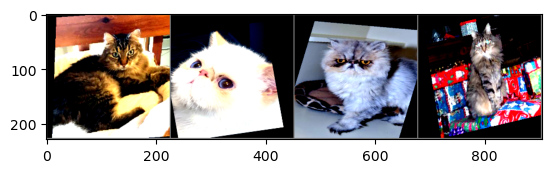

In [45]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:4]))

# Implementation of early stopping

In [20]:
class EarlyStopping:
    def __init__(self, tolerance=5, min_delta=0):
        self.tolerance = tolerance
        self.min_delta = min_delta
        self.counter = 0
        self.early_stop = False
        self.best_loss = float('inf')

    def __call__(self, loss):
        if (self.best_loss - loss) < self.min_delta:
            self.counter += 1
            if self.counter >= self.tolerance:
                self.early_stop = True
        else:
            self.best_loss = loss
            self.counter = 0

        return self.early_stop

# Model design

### VGG16 architecture

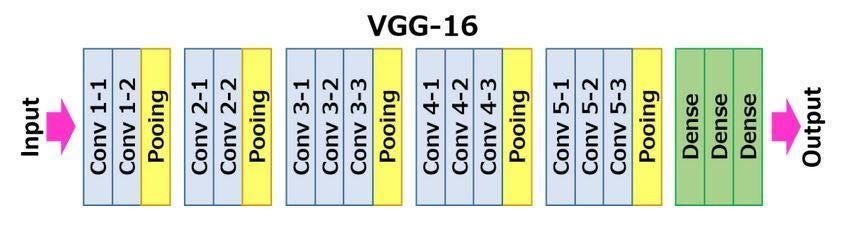

In [21]:
VGG16 = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M']

class VGGNet(nn.Module):
    def __init__(self, in_channels = 3, num_classes = 20):
        super(VGGNet, self).__init__()
        self.in_channels = in_channels
        self.conv_layers = self.create_conv_layers(VGG16)
        self.fcs = nn.Sequential(
            nn.Linear(25088, 4096),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fcs(x)
        return x

    def create_conv_layers(self, architecture):
        layers = []
        in_channels = self.in_channels
        for x in architecture:
            if type(x) == int:
                out_channels = x
                layers += [nn.Conv2d(in_channels=in_channels,
                                     out_channels=out_channels,
                                     kernel_size=(3,3),
                                     stride=(1,1),
                                     padding=(1,1)),
                            nn.BatchNorm2d(x),
                            nn.ReLU()]
                in_channels = x
            elif x == 'M':
                layers += [nn.MaxPool2d(kernel_size=(2,2), stride=(2,2))]

        return nn.Sequential(*layers)

In [22]:
# Hiperparameters
learning_rate = 0.001

In [20]:
# Model initialization with choice of evaluation criterion and optimizer
model = VGGNet().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# Evaluation metrics

Recall measures how well the model detects cases of a given class. Precision measures how many of the cases classified into a given class actually belong to that class. In the case of our multiclass classification, recall and precision are calculated separately for each class. It is possible to provide averaged metrics for all classes, but providing values for each class can offer more insights into the model's performance.

Accuracy measures the overall proportion of correct predictions, while precision and recall provide class-specific insights into the model's ability to correctly identify instances of each class.

In [21]:
class compute_metrics():
    def __init__(self):
        pass

    @staticmethod
    # Accuracy = (TP + TN) / (TP + TN + FP + FN)
    def accuracy(model, data_loader):
        model.eval()
        n_correct = 0
        n_samples = 0
        with torch.no_grad():
            for X, y in data_loader:
                X = X.to(device)
                y = y.to(device)
                pred = model(X)
                _, prediction = pred.max(1)
                n_correct += (prediction == y).sum().item()
                n_samples += prediction.size(0)
        accuracy = n_correct / n_samples * 100
        return accuracy

    @staticmethod
    def average_loss(model, data_loader):
        model.eval()
        total_loss = 0.0
        n_samples = 0
        with torch.no_grad():
            for X, y in data_loader:
                X = X.to(device)
                y = y.to(device)
                pred = model(X)
                loss = criterion(pred, y)
                total_loss += loss.item() * X.size(0)
                n_samples += X.size(0)
        average_loss = total_loss / n_samples
        return average_loss


    @staticmethod
    # Precision = TP / (TP + FP)
    def precision(model, data_loader, num_classes = 20):
        model.eval()
        correct_positives = [0] * num_classes
        all_positives = [0] * num_classes

        with torch.no_grad():
            for X, y in data_loader:
                X = X.to(device)
                y = y.to(device)
                pred = model(X)
                _, predictions = pred.max(1)

                for class_idx in range(num_classes):
                    correct_positives[class_idx] += ((predictions == class_idx) & (y == class_idx)).sum().item()
                    all_positives[class_idx] += (predictions == class_idx).sum().item()

        precision = [correct_positives[i] / all_positives[i] if all_positives[i] > 0 else 0 for i in range(num_classes)]
        precision_percent = [p * 100 for p in precision]
        return precision_percent

    @staticmethod
    # Recall = TP / (TP + FN)
    def recall(model, data_loader, num_classes = 20):
        model.eval()
        correct_positives = [0] * num_classes
        all_actual_positives = [0] * num_classes

        with torch.no_grad():
            for X, y in data_loader:
                X = X.to(device)
                y = y.to(device)
                pred = model(X)
                _, predictions = pred.max(1)

                for class_idx in range(num_classes):
                    correct_positives[class_idx] += ((predictions == class_idx) & (y == class_idx)).sum().item()
                    all_actual_positives[class_idx] += (y == class_idx).sum().item()

        recall = [correct_positives[i] / all_actual_positives[i] if all_actual_positives[i] > 0 else 0 for i in range(num_classes)]
        recall_percent = [r * 100 for r in recall]
        return recall_percent

    @staticmethod
    def F1_score(recall, precision, epsilon=1e-7):
        f1 = 2 * (precision * recall) / (precision + recall + epsilon)
        return f1

# Training

In [26]:
def train_one_epoch(model, dataloader):
    model.train()
    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for X, y in dataloader:
        X = X.to(device)
        y = y.to(device).long()  # Ensure that labels are of type Long (torch.int64)

        pred = model(X)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Calculating accuracy
        _, predicted = torch.max(pred.data, 1)
        total_samples += y.size(0)
        correct_predictions += (predicted == y).sum().item()

    # Calculate average loss and accuracy
    average_loss = total_loss / len(dataloader)
    accuracy = correct_predictions / total_samples * 100
    return average_loss, accuracy


In [27]:
def validate_one_epoch(model, dataloader):
    model.eval()
    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device).long()  # Ensure that labels are of type Long (torch.int64)

            pred = model(X)
            loss = criterion(pred, y)

            total_loss += loss.item()

            # Calculating accuracy
            _, predicted = torch.max(pred.data, 1)
            total_samples += y.size(0)
            correct_predictions += (predicted == y).sum().item()

    # Calculate average loss and accuracy
    average_loss = total_loss / len(dataloader)
    accuracy = correct_predictions / total_samples * 100
    return average_loss, accuracy

In [28]:
def train_with_early_stopping(model, train_loader, valid_loader, early_stopping, scheduler, filename, num_epochs=100):
    train_losses = []
    valid_losses = []
    train_accuracies = []
    valid_accuracies = []
    early_stopping_epoch = None
    best_valid_accuracy = 0.0
    best_epoch = 0

    # Initialize file to store training outcomes
    with open(filename, 'a') as file:
        file.write("Epoch, Train Loss, Train Accuracy, Valid Loss, Valid Accuracy\n")

        for epoch in range(num_epochs):
            print(f"Epoch {epoch + 1}")

            # Training
            train_loss, train_accuracy = train_one_epoch(model, train_loader)
            train_losses.append(train_loss)
            train_accuracies.append(train_accuracy)
            print(f"Train Loss: {train_loss:.6f}, Train Accuracy: {train_accuracy:.2f}%")

            # Validation
            valid_loss, valid_accuracy = validate_one_epoch(model, valid_loader)
            valid_losses.append(valid_loss)
            valid_accuracies.append(valid_accuracy)
            print(f"Valid Loss: {valid_loss:.6f}, Valid Accuracy: {valid_accuracy:.2f}%")

            # Save outcomes from the epoch
            file.write(f"{epoch + 1}, {train_loss:.6f}, {train_accuracy:.2f}%, {valid_loss:.6f}, {valid_accuracy:.2f}%\n")

            # We check for best evaluation metrics. If the current one is better,
            # then the updated model is saved as the best one.
            if valid_accuracy > best_valid_accuracy:
                best_valid_accuracy = valid_accuracy
                best_epoch = epoch
                torch.save(model.state_dict(), f"best_model_epoch_{epoch+1}.pth")
                print(f"New best model saved with {valid_accuracy:.2f}% accuracy at epoch {epoch + 1}")

            # Checking for necessity of early stopping
            early_stopping(valid_loss)
            if early_stopping.early_stop:
                early_stopping_epoch = epoch
                print(f"Early stopping triggered at epoch {epoch + 1}")
                break
                
            scheduler.step()

    return train_losses, valid_losses, train_accuracies, valid_accuracies, early_stopping_epoch, best_valid_accuracy, best_epoch

In [ ]:
early_stopping = EarlyStopping(tolerance=10, min_delta=0.01)
train_losses, valid_losses, train_accuracies, valid_accuracies, early_stopping_epoch, best_valid_acc, best_epoc = train_with_early_stopping(model,
                                                                                                                                            train_loader,
                                                                                                                                            valid_loader,
                                                                                                                                            early_stopping,
                                                                                                                                            scheduler,
                                                                                                                                            f'training_results.dat')

<code>Epoch 1
Train Loss: 0.399790, Train Accuracy: 86.20%
Valid Loss: 1.559491, Valid Accuracy: 61.29%
New best model saved with 61.29% accuracy at epoch 1
Epoch 2
Train Loss: 0.411854, Train Accuracy: 85.75%
Valid Loss: 1.761686, Valid Accuracy: 59.86%
Epoch 3
Train Loss: 0.418325, Train Accuracy: 85.38%
Valid Loss: 1.599945, Valid Accuracy: 62.86%
New best model saved with 62.86% accuracy at epoch 3
Epoch 4
Train Loss: 0.399407, Train Accuracy: 85.96%
Valid Loss: 2.062503, Valid Accuracy: 59.00%
Epoch 5
Train Loss: 0.368920, Train Accuracy: 87.07%
Valid Loss: 1.795445, Valid Accuracy: 58.43%
Epoch 6
Train Loss: 0.294711, Train Accuracy: 90.04%
Valid Loss: 1.418117, Valid Accuracy: 66.14%
New best model saved with 66.14% accuracy at epoch 6
Epoch 7
Train Loss: 0.251629, Train Accuracy: 91.96%
Valid Loss: 1.412843, Valid Accuracy: 66.43%
New best model saved with 66.43% accuracy at epoch 7
Epoch 8
Train Loss: 0.235888, Train Accuracy: 92.71%
Valid Loss: 1.436342, Valid Accuracy: 66.00%
Epoch 9
Train Loss: 0.212618, Train Accuracy: 93.09%
Valid Loss: 1.423208, Valid Accuracy: 67.00%
New best model saved with 67.00% accuracy at epoch 9
Epoch 10
Train Loss: 0.221426, Train Accuracy: 92.70%
Valid Loss: 1.428592, Valid Accuracy: 67.14%
New best model saved with 67.14% accuracy at epoch 10
Epoch 11
Train Loss: 0.212757, Train Accuracy: 92.82%
Valid Loss: 1.451139, Valid Accuracy: 67.00%
Epoch 12
Train Loss: 0.201609, Train Accuracy: 93.59%
Valid Loss: 1.448556, Valid Accuracy: 67.29%
New best model saved with 67.29% accuracy at epoch 12
Epoch 13
Train Loss: 0.195397, Train Accuracy: 93.79%
Valid Loss: 1.439127, Valid Accuracy: 67.14%
Epoch 14
Train Loss: 0.194031, Train Accuracy: 93.41%
Valid Loss: 1.444524, Valid Accuracy: 66.43%
Epoch 15
Train Loss: 0.202516, Train Accuracy: 93.36%
Valid Loss: 1.441113, Valid Accuracy: 67.00%
Epoch 16
Train Loss: 0.210535, Train Accuracy: 93.23%
Valid Loss: 1.443673, Valid Accuracy: 67.00%
Early stopping triggered at epoch 16
</code>

The above output only represents the initial phase of training, which took a long time and was executed in parts.

# Training outcome

In [ ]:
model.load_state_dict(torch.load('best_model.pth', map_location=torch.device('cpu')))

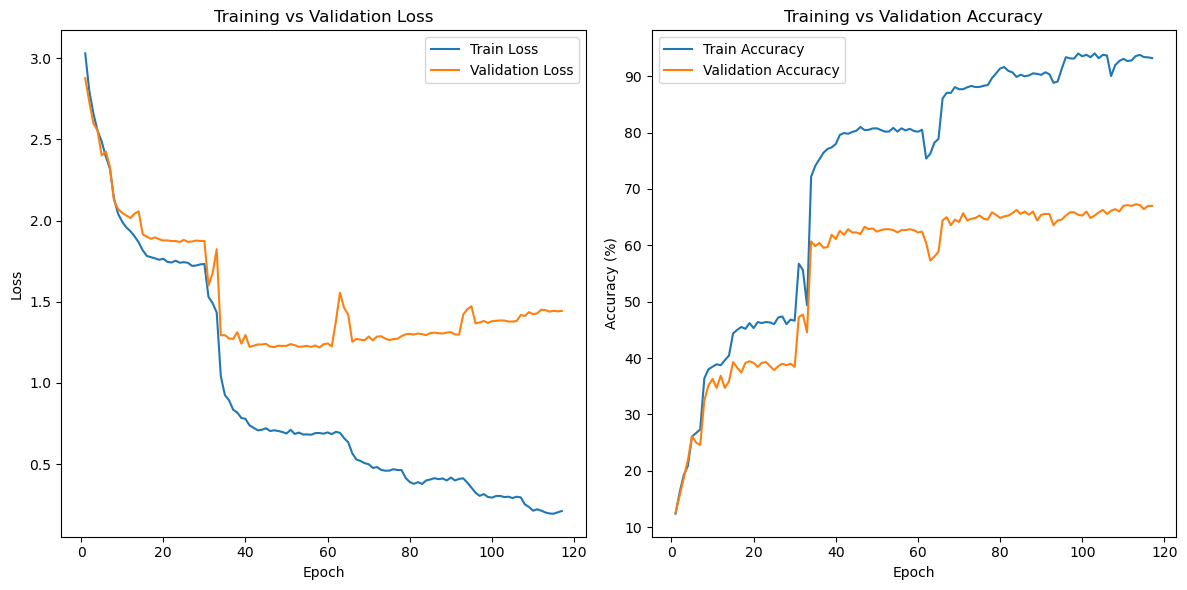

In [34]:
file_path = 'training_results.dat'
df = pd.read_csv(file_path)

df['Train Accuracy'] = df['Train Accuracy'].str.rstrip('%').astype('float')
df['Valid Accuracy'] = df['Valid Accuracy'].str.rstrip('%').astype('float')

plt.figure(figsize=(12, 6))

# Loss function plot
plt.subplot(1, 2, 1)
plt.plot(df['Epoch'], df['Train Loss'], label='Train Loss')
plt.plot(df['Epoch'], df['Valid Loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(df['Epoch'], df['Train Accuracy'], label='Train Accuracy')
plt.plot(df['Epoch'], df['Valid Accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

Based on the above graphs, we can draw the following conclusions regarding the model's training:

* **Decrease in Loss:** There is a noticeable overall downward trend in both training and validation loss, indicating that the model is improving and better fitting the data with each epoch.

* **Learning Dynamics:** The validation loss values show some fluctuations, which may suggest that the model encountered more difficult cases to learn or that there were fluctuations in the learning process.

* **Model Accuracy:** Accuracy for both training and validation data generally increases, indicating that the model is learning correctly. However, some drops in the validation accuracy graph suggest potential overfitting — the model may be fitting the training data too closely at the cost of generalizing well. This could be related to the relatively small training dataset (5600 images).

# Model evaluation

In [35]:
def predict(model, image, classes):
    model.eval()
    o
    if isinstance(image, torch.Tensor):
        img_batch = image.unsqueeze(0).to(device)
    else:
        img = Image.open(image)
        img_transformed = transform(img)


        img_batch = img_transformed.unsqueeze(0).to(device)

    with torch.no_grad():
        _, predicted_idx = model(img_batch).max(1)

    predicted_class = classes[predicted_idx.item()]

    return predicted_class

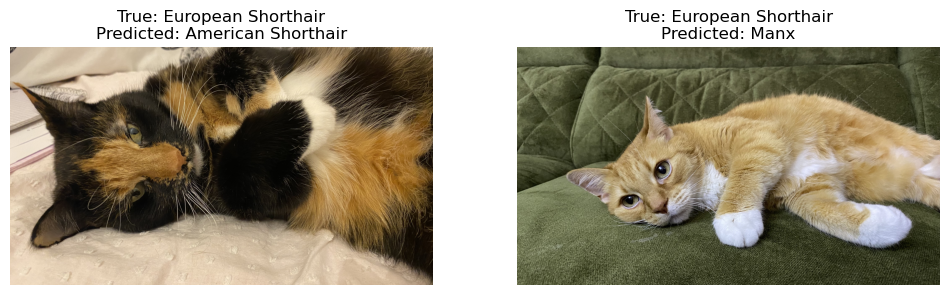

In [59]:
image_path1 = 'Nala.jpeg'
image_path2 = 'Diego.jpeg'

img1 = Image.open(image_path1)
img2 = Image.open(image_path2)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img1)
axes[0].axis('off')
axes[0].set_title(f'True: European Shorthair\nPredicted: {predict(model, "Nala.jpeg", classes)}') 

axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title(f'True: European Shorthair\nPredicted: {predict(model, "Diego.jpeg", classes)}') 

plt.show()

In [60]:
print(f'Accuracy for test data: {compute_metrics.accuracy(model, test_loader):.2f}%.')

Accuracy for test data: 68.86%.


In [42]:
recall = compute_metrics.recall(model, test_loader)
precision =  compute_metrics.precision(model, test_loader)

In [46]:
f1_score = [compute_metrics.F1_score(r, p) for r, p in zip(recall, precision)]

In [61]:
pd.DataFrame({'Class': classes, "Recall": recall, "Precision": precision, 'F1 score': f1_score})

,Class,Recall,Precision,F1 score
0,Abyssinian,80.000000,70.000000,74.666667
1,American Bobtail,22.857143,23.529412,23.188406
2,American Curl,65.714286,67.647059,66.666667
3,American Shorthair,51.428571,56.250000,53.731343
4,Bengal,74.285714,66.666667,70.270270
5,Birman,65.714286,69.696970,67.647059
6,Bombay,80.000000,71.794872,75.675676
7,British Shorthair,62.857143,66.666667,64.705882
8,Egyptian Mau,80.000000,70.000000,74.666667
9,Exotic Shorthair,80.000000,87.500000,83.582090


The analysis of the model's performance on the test data for cat breed classification shows varying levels of effectiveness depending on the breed. Based on the values of metrics such as recall and precision, several interesting conclusions can be drawn for individual breeds:

1. **Abyssinian:** High recall (80.00%) and good precisiom (70.00%). The model performs well in recognizing this breed but occasionally confuses it with other breeds.

2. **American Bobtail:** The model struggles significantly with this breed. Both recall (22.86%) and precision (23.53%) are low, suggesting that the model fails to recognize this breed accurately and often misclassifies it as something else.

3. **Sphynx:** The model excels in identifying Sphynx cats, with both high recall (91.43%) and precision (84.21%). This means the model correctly identifies most Sphynx cats and rarely misidentifies them.

4. **Maine Coon i Ragdoll:** While the model often misses these breeds (indicated by the medium recall), it is very accurate when it does recognize them (high precision). This suggests that the model is conservative in predicting these breeds, but when it does, it is very reliable.

5. **Scottish Fold:** The model performs excellently with this breed, with both recall (88.57%) and precision (86.11%) being very high. It indicates that the model has a strong capability to recognize and classify Scottish Fold cats accurately.

Overall, the model's performance varies across different cat breeds. Some breeds, like Sphynx and Scottish Fold, are recognized with high accuracy and sensitivity, whereas others, like American Bobtail, are challenging for the model to identify correctly. This variability could be attributed to several factors, including the distinctive features of certain breeds, the diversity of training data for each class, or the inherent difficulty in differentiating between some breeds.

This analysis suggests that improvements can be made in terms of data augmentation, additional training data for underrepresented breeds, or model fine-tuning for breeds that are currently more difficult to recognize.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


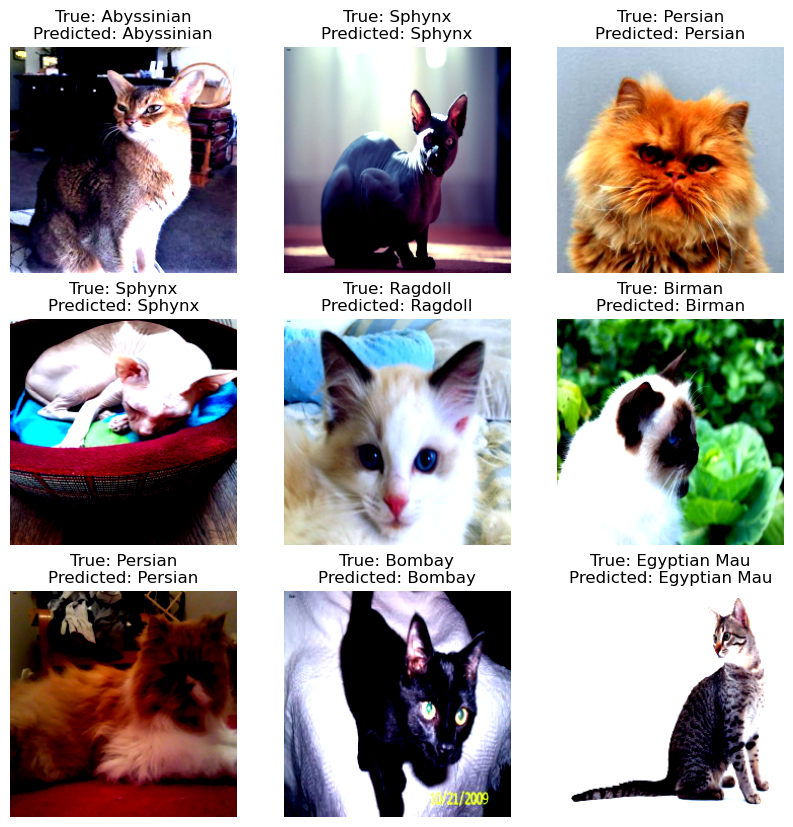

In [48]:
def visualize_predictions(model, dataset, classes, transform, num_examples=9):
    model.eval()

    examples = np.random.choice(len(dataset), num_examples, replace=False)

    fig, axes = plt.subplots(3, 3, figsize=(10, 10))

    for i, example_idx in enumerate(examples):
        image, true_class = dataset[example_idx]
        predicted_class = predict(model, image, classes)

        if isinstance(image, torch.Tensor):
            image_display = np.transpose(torchvision.utils.make_grid(image / 2 + 0.5).cpu().numpy(), (1, 2, 0))
        else:
            image_display = np.transpose(torchvision.utils.make_grid(transform(image / 2 + 0.5)).cpu().numpy(), (1, 2, 0))

        axes[i // 3, i % 3].imshow(image_display)
        axes[i // 3, i % 3].set_title(f'True: {classes[true_class]}\nPredicted: {predicted_class}')
        axes[i // 3, i % 3].axis('off')

    plt.show()


visualize_predictions(model, cat_dataset_test, classes, transform)